## Results of Arabic-English code-switched social media slang Dataset
- After preporcessing and fix our high imbalance and mislabeled dataset that was a huge challenge.
- we will Compares all trained models across accuracy, precision, recall, F1, and training/inference time.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
# ── Result JSON paths ─────────────────────────────────────────────────────────
RESULT_PATHS = {
    'ml_tfidf':     'Trained models/ML models/results.json',
    'ml_svd':       'Trained models/ML models/results_SVD.json',
    'lstm':         'Trained models/LSTM/results.json',
    'xlm_roberta':  'Trained models/XML-RoBERTA-transformer/results.json',
    'twitter_base': 'Trained models/transformer twitter base/results.json',
}

# ── Classification report paths ───────────────────────────────────────────────
REPORT_PATHS = {
    'LR (TF-IDF)':         'Trained models/ML models/LogisticRegression/LogisticRegression_report.txt',
    'MNB (TF-IDF)':        'Trained models/ML models/MultinomialNB/MultinomialNB_report.txt',
    'CNB (TF-IDF)':        'Trained models/ML models/ComplementNB/ComplementNB_report.txt',
    'XGBoost (TF-IDF)':    'Trained models/ML models/XGBoost/XGBoost_report.txt',
    'LR (SVD)':            'Trained models/ML models/LogisticRegression_with_SVD/LogisticRegression_report.txt',
    'XGBoost (SVD)':       'Trained models/ML models/XGBoost_with_SVD/XGBoost_report.txt',
    'LSTM (fastText)':     'Trained models/LSTM/LSTM_fasttext_test_report.txt',
    'XLM-RoBERTa-base':    'Trained models/XML-RoBERTA-transformer/test_report.txt',
    'Twitter-XLM-RoBERTa': 'Trained models/transformer twitter base/test_report.txt',
}

In [10]:
def _row(name, model_type, train, test, train_time, test_time):
    return {
        'Model':           name,
        'Type':            model_type,
        'Train F1':        train['f1'],
        'Train Acc':       train['accuracy'],
        'Train Precision': train['precision'],
        'Train Recall':    train['recall'],
        'Test F1':         test['f1'],
        'Test Acc':        test['accuracy'],
        'Test Precision':  test['precision'],
        'Test Recall':     test['recall'],
        'Train Time (s)':  train_time,
        'Test Time (s)':   test_time,
    }

records = []

# ── ML TF-IDF ─────────────────────────────────────────────────────────────────
with open(RESULT_PATHS['ml_tfidf']) as f:
    ml = json.load(f)

for key, name in [('LogisticRegression', 'LR (TF-IDF)'),
                   ('MultinomialNB',      'MNB (TF-IDF)'),
                   ('ComplementNB',       'CNB (TF-IDF)'),
                   ('XGBoost',            'XGBoost (TF-IDF)')]:
    d = ml[key]
    records.append(_row(name, 'ML (TF-IDF)', d['train'], d['test'],
                        d['train_time_sec'], d['test_time_sec']))

# ── ML SVD ────────────────────────────────────────────────────────────────────
with open(RESULT_PATHS['ml_svd']) as f:
    ml_svd = json.load(f)

for key, name in [('LogisticRegression', 'LR (SVD)'),
                   ('XGBoost',            'XGBoost (SVD)')]:
    d = ml_svd[key]
    records.append(_row(name, 'ML (SVD)', d['train'], d['test'],
                        d['train_time_sec'], d['test_time_sec']))

# ── LSTM (GRU excluded — failed run) ──────────────────────────────────────────
with open(RESULT_PATHS['lstm']) as f:
    lstm = json.load(f)
d = lstm['LSTM_fasttext']
records.append(_row('LSTM (fastText)', 'RNN',
                    d['val'], d['test'],
                    d['train_time_sec'], d['test_time_sec']))

# ── XLM-RoBERTa-base ──────────────────────────────────────────────────────────
with open(RESULT_PATHS['xlm_roberta']) as f:
    xlm = json.load(f)
records.append(_row('XLM-RoBERTa-base', 'Transformer',
                    xlm['train'], xlm['test'],
                    xlm['train_time_sec'], xlm['test_time_sec']))

# ── Twitter-XLM-RoBERTa (loaded when available) ───────────────────────────────
if os.path.exists(RESULT_PATHS['twitter_base']):
    with open(RESULT_PATHS['twitter_base']) as f:
        tw = json.load(f)
    records.append(_row('Twitter-XLM-RoBERTa', 'Transformer',
                        tw['train'], tw['test'],
                        tw['train_time_sec'], tw['test_time_sec']))

df = pd.DataFrame(records).set_index('Model').sort_values(by='Test F1',ascending=False)
print(f'Loaded {len(df)} models')
df

Loaded 8 models


,Type,Train F1,Train Acc,Train Precision,Train Recall,Test F1,Test Acc,Test Precision,Test Recall,Train Time (s),Test Time (s)
Model,,,,,,,,,,,
XLM-RoBERTa-base,Transformer,0.8726,0.8643,0.8823,0.8682,0.8692,0.8518,0.8905,0.8518,6422.9000,37.8300
MNB (TF-IDF),ML (TF-IDF),0.8660,0.8672,0.8675,0.8672,0.8455,0.8476,0.8441,0.8476,0.0000,0.0000
LR (TF-IDF),ML (TF-IDF),0.8706,0.8657,0.8823,0.8657,0.8433,0.8244,0.8655,0.8244,22.1800,0.0000
XGBoost (TF-IDF),ML (TF-IDF),0.8925,0.8950,0.9005,0.8950,0.8377,0.8433,0.8378,0.8433,65.4000,0.0700
LSTM (fastText),RNN,0.7880,0.7890,0.7878,0.7890,0.8320,0.8207,0.8445,0.8207,530.3800,0.5700
XGBoost (SVD),ML (SVD),0.9619,0.9620,0.9631,0.9620,0.8005,0.8121,0.7941,0.8121,1547.8600,0.1600
CNB (TF-IDF),ML (TF-IDF),0.8059,0.7721,0.8684,0.7721,0.7978,0.7433,0.8696,0.7433,0.0000,0.0000
LR (SVD),ML (SVD),0.8100,0.8033,0.8278,0.8033,0.7952,0.7644,0.8382,0.7644,117.0900,0.0200


--> Here we can see as overall Multinomial Nave Bayes is best balance between F1-score and inference time

---
## Metrics Summary

In [4]:
cols = ['Test F1', 'Test Acc', 'Test Precision', 'Test Recall',
        'Train F1', 'Train Acc', 'Train Precision', 'Train Recall']

summary = df[cols].sort_values('Test F1', ascending=False)

def highlight_best(s):
    return ['background-color: #d4edda; font-weight: bold'
            if v == s.max() else '' for v in s]

summary.style.apply(highlight_best).format('{:.4f}')

,Test F1,Test Acc,Test Precision,Test Recall,Train F1,Train Acc,Train Precision,Train Recall
Model,,,,,,,,
XLM-RoBERTa-base,0.8692,0.8518,0.8905,0.8518,0.8726,0.8643,0.8823,0.8682
MNB (TF-IDF),0.8455,0.8476,0.8441,0.8476,0.8660,0.8672,0.8675,0.8672
LR (TF-IDF),0.8433,0.8244,0.8655,0.8244,0.8706,0.8657,0.8823,0.8657
XGBoost (TF-IDF),0.8377,0.8433,0.8378,0.8433,0.8925,0.8950,0.9005,0.8950
LSTM (fastText),0.8320,0.8207,0.8445,0.8207,0.7880,0.7890,0.7878,0.7890
XGBoost (SVD),0.8005,0.8121,0.7941,0.8121,0.9619,0.9620,0.9631,0.9620
CNB (TF-IDF),0.7978,0.7433,0.8696,0.7433,0.8059,0.7721,0.8684,0.7721
LR (SVD),0.7952,0.7644,0.8382,0.7644,0.8100,0.8033,0.8278,0.8033


---
## Test Performance Comparison

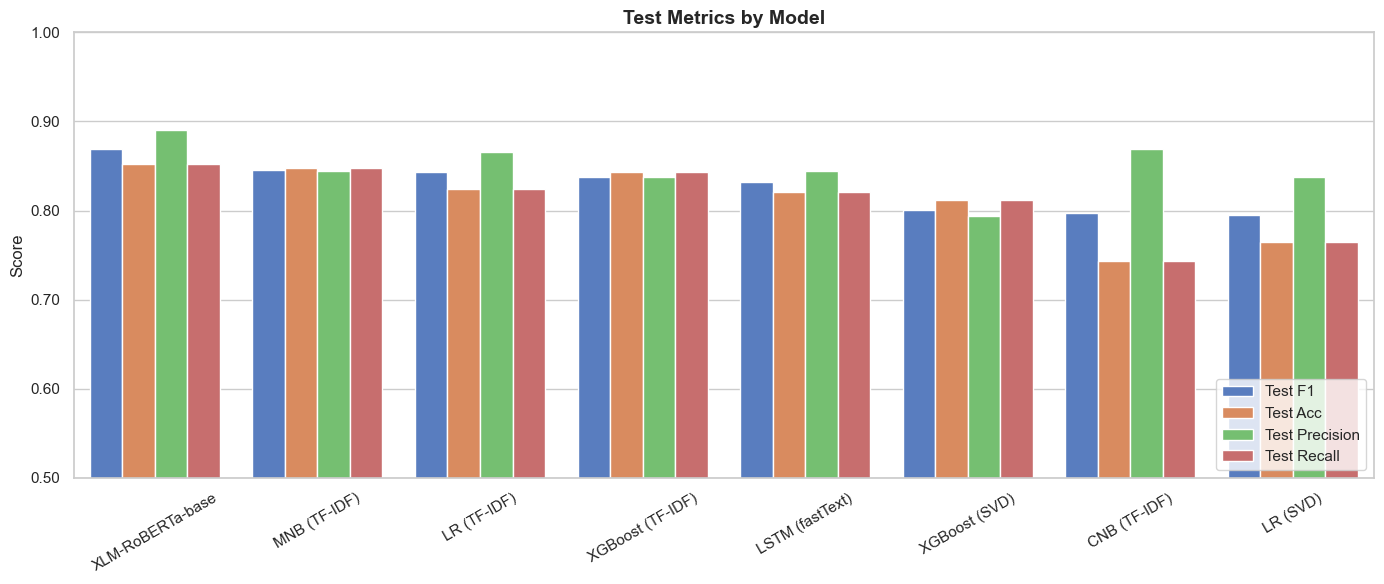

In [11]:
test_cols = ['Test F1', 'Test Acc', 'Test Precision', 'Test Recall']
plot_df   = df[test_cols].sort_values('Test F1', ascending=False).reset_index()
plot_long = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_long, x='Model', y='Score', hue='Metric', ax=ax)
ax.set_ylim(0.5, 1.0)
ax.set_title('Test Metrics by Model', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


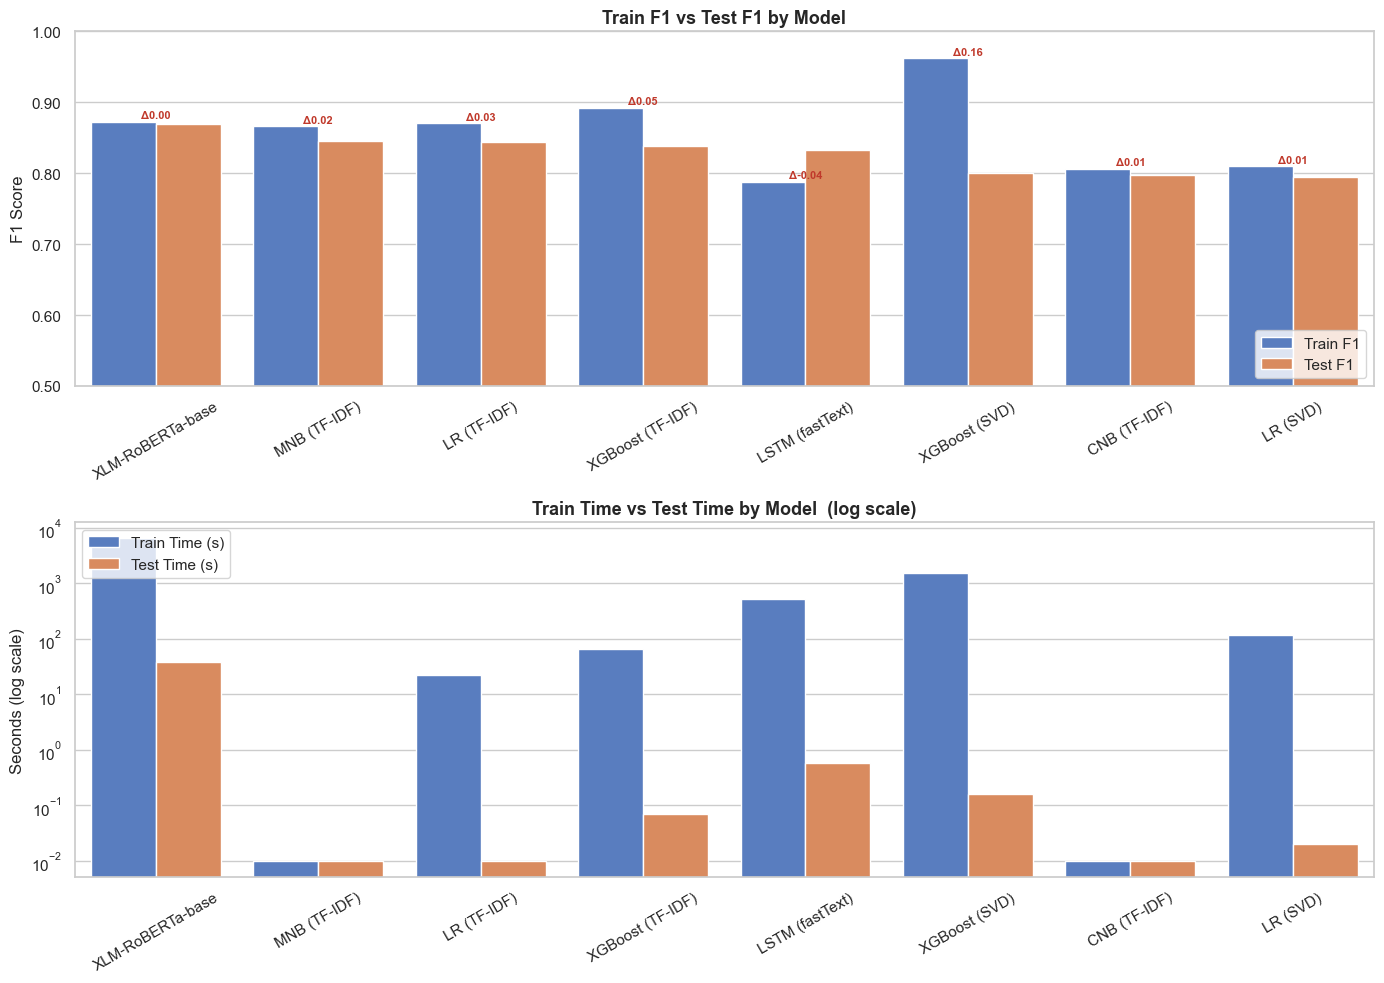

In [12]:
plot_df = df[['Train F1', 'Test F1', 'Train Time (s)', 'Test Time (s)']]\
            .sort_values('Test F1', ascending=False).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Train F1 vs Test F1 ───────────────────────────────────────────────────────
f1_long = plot_df[['Model', 'Train F1', 'Test F1']]\
            .melt(id_vars='Model', var_name='Split', value_name='F1')
sns.barplot(data=f1_long, x='Model', y='F1', hue='Split', ax=ax1)
ax1.set_ylim(0.5, 1.0)
ax1.set_title('Train F1 vs Test F1 by Model', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('F1 Score')
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
for i, row in plot_df.iterrows():
    gap = row['Train F1'] - row['Test F1']
    ax1.text(i, row['Train F1'] + 0.005, f'Δ{gap:.2f}',
             ha='center', fontsize=8, color='#c0392b', fontweight='bold')
ax1.legend(loc='lower right')

# ── Train Time vs Test Time (log scale) ───────────────────────────────────────
time_long = plot_df[['Model', 'Train Time (s)', 'Test Time (s)']]\
              .melt(id_vars='Model', var_name='Phase', value_name='Seconds')
time_long['Seconds'] = time_long['Seconds'].clip(lower=0.01)  # avoid log(0)
sns.barplot(data=time_long, x='Model', y='Seconds', hue='Phase', ax=ax2)
ax2.set_yscale('log')
ax2.set_title('Train Time vs Test Time by Model  (log scale)', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Seconds (log scale)')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## Classification Reports

In [8]:
for model_name, path in REPORT_PATHS.items():
    if not os.path.exists(path):
        continue
    with open(path, encoding='utf-8') as f:
        content = f.read()
    print('=' * 60)
    print(f'  {model_name}')
    print('=' * 60)
    print(content)
    print()

  LR (TF-IDF)

LogisticRegression — TRAIN Classification Report
              precision    recall  f1-score   support

    negative       0.87      0.88      0.87     10815
     neutral       0.48      0.90      0.63      1176
    positive       0.92      0.86      0.89     15121

    accuracy                           0.87     27112
   macro avg       0.76      0.88      0.80     27112
weighted avg       0.88      0.87      0.87     27112


LogisticRegression — TEST Classification Report
              precision    recall  f1-score   support

    negative       0.84      0.83      0.83      3705
     neutral       0.05      0.29      0.09       100
    positive       0.90      0.83      0.87      5317

    accuracy                           0.82      9122
   macro avg       0.60      0.65      0.60      9122
weighted avg       0.87      0.82      0.84      9122


  MNB (TF-IDF)

MultinomialNB — TRAIN Classification Report
              precision    recall  f1-score   support

    negat

Here as we can see the neutral because this have problems in mislabeling that we tried to solve it as we can and also have high imbalance (7 * smaller than our majority class)  this class is the one with the poorest results, but this is not the most interesting class by the way, not like our negative or positive classes

- --> as Company I will high recommend models that have high Recall on Negative class more that others
- --> Since we want to pay more attention to the problems we have so we can solve them
----------------
- So we can use XLM-RoBERTa-base model if we want higher overall results specially Negative Class
-------------------
- But I Recommend using Multinomial Nave Bayes model as this is more better in inference time and optimized more for computation resources with also give high overall results with high Negative class recall